In [1]:
import h5py

In [2]:
mesh_2_file = h5py.File('/scratch/saporito/Frag3D/mesh_3/data.h5', 'r')

In [3]:
sorted_keys_m2 = sorted(mesh_2_file.keys(), key=lambda x: int(x.split('_')[-1]))
print("Sorted keys in mesh_2_file:", sorted_keys_m2)

Sorted keys in mesh_2_file: ['step_0', 'step_55', 'step_110', 'step_165', 'step_220', 'step_275', 'step_330', 'step_385', 'step_440', 'step_495', 'step_550', 'step_605', 'step_660', 'step_715', 'step_770', 'step_825', 'step_880', 'step_935', 'step_990', 'step_1045', 'step_1100', 'step_1155', 'step_1210', 'step_1265', 'step_1320', 'step_1375', 'step_1430', 'step_1485', 'step_1540', 'step_1595', 'step_1650', 'step_1705', 'step_1760', 'step_1815', 'step_1870', 'step_1925', 'step_1980', 'step_2035', 'step_2090', 'step_2145', 'step_2200', 'step_2255', 'step_2310', 'step_2365', 'step_2420', 'step_2475', 'step_2530', 'step_2585', 'step_2640', 'step_2695', 'step_2750', 'step_2805', 'step_2860', 'step_2915', 'step_2970', 'step_3025', 'step_3080', 'step_3135', 'step_3190', 'step_3245', 'step_3300', 'step_3355', 'step_3410', 'step_3465', 'step_3520', 'step_3575', 'step_3630', 'step_3685', 'step_3740', 'step_3795', 'step_3850', 'step_3905', 'step_3960', 'step_4015', 'step_4070', 'step_4125', 'step

In [4]:
final_step_mesh_2 = mesh_2_file['step_55610']

In [5]:
print(final_step_mesh_2.attrs.keys())

<KeysViewHDF5 ['econ', 'edis', 'ekin', 'epot', 'erev', 'nb_fragments', 'time', 'total_energy', 'work']>


In [6]:
final_time = final_step_mesh_2.attrs['time']
print(final_time)

3.999995730936114e-05


In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# Savding variation of ['econ', 'edis', 'ekin', 'epot', 'erev', 'nb_fragments', 'time', 'total_energy', 'work']
# wrt their value in step_0 at each step
econ = []
edis = []
ekin = []
epot = []
erev = []
nb_fragments = []
total_energy = []
for step in sorted_keys_m2:
    step_data = mesh_2_file[step]
    econ.append(step_data.attrs['econ'])
    edis.append(step_data.attrs['edis'])
    ekin.append(step_data.attrs['ekin'])
    epot.append(step_data.attrs['epot'])
    erev.append(step_data.attrs['erev'])
    nb_fragments.append(step_data.attrs['nb_fragments'])
    total_energy.append(step_data.attrs['total_energy'])
steps = np.array(sorted_keys_m2)
econ = np.array(econ)
edis = np.array(edis)
ekin = np.array(ekin)
epot = np.array(epot)
erev = np.array(erev)
nb_fragments = np.array(nb_fragments)
total_energy = np.array(total_energy)

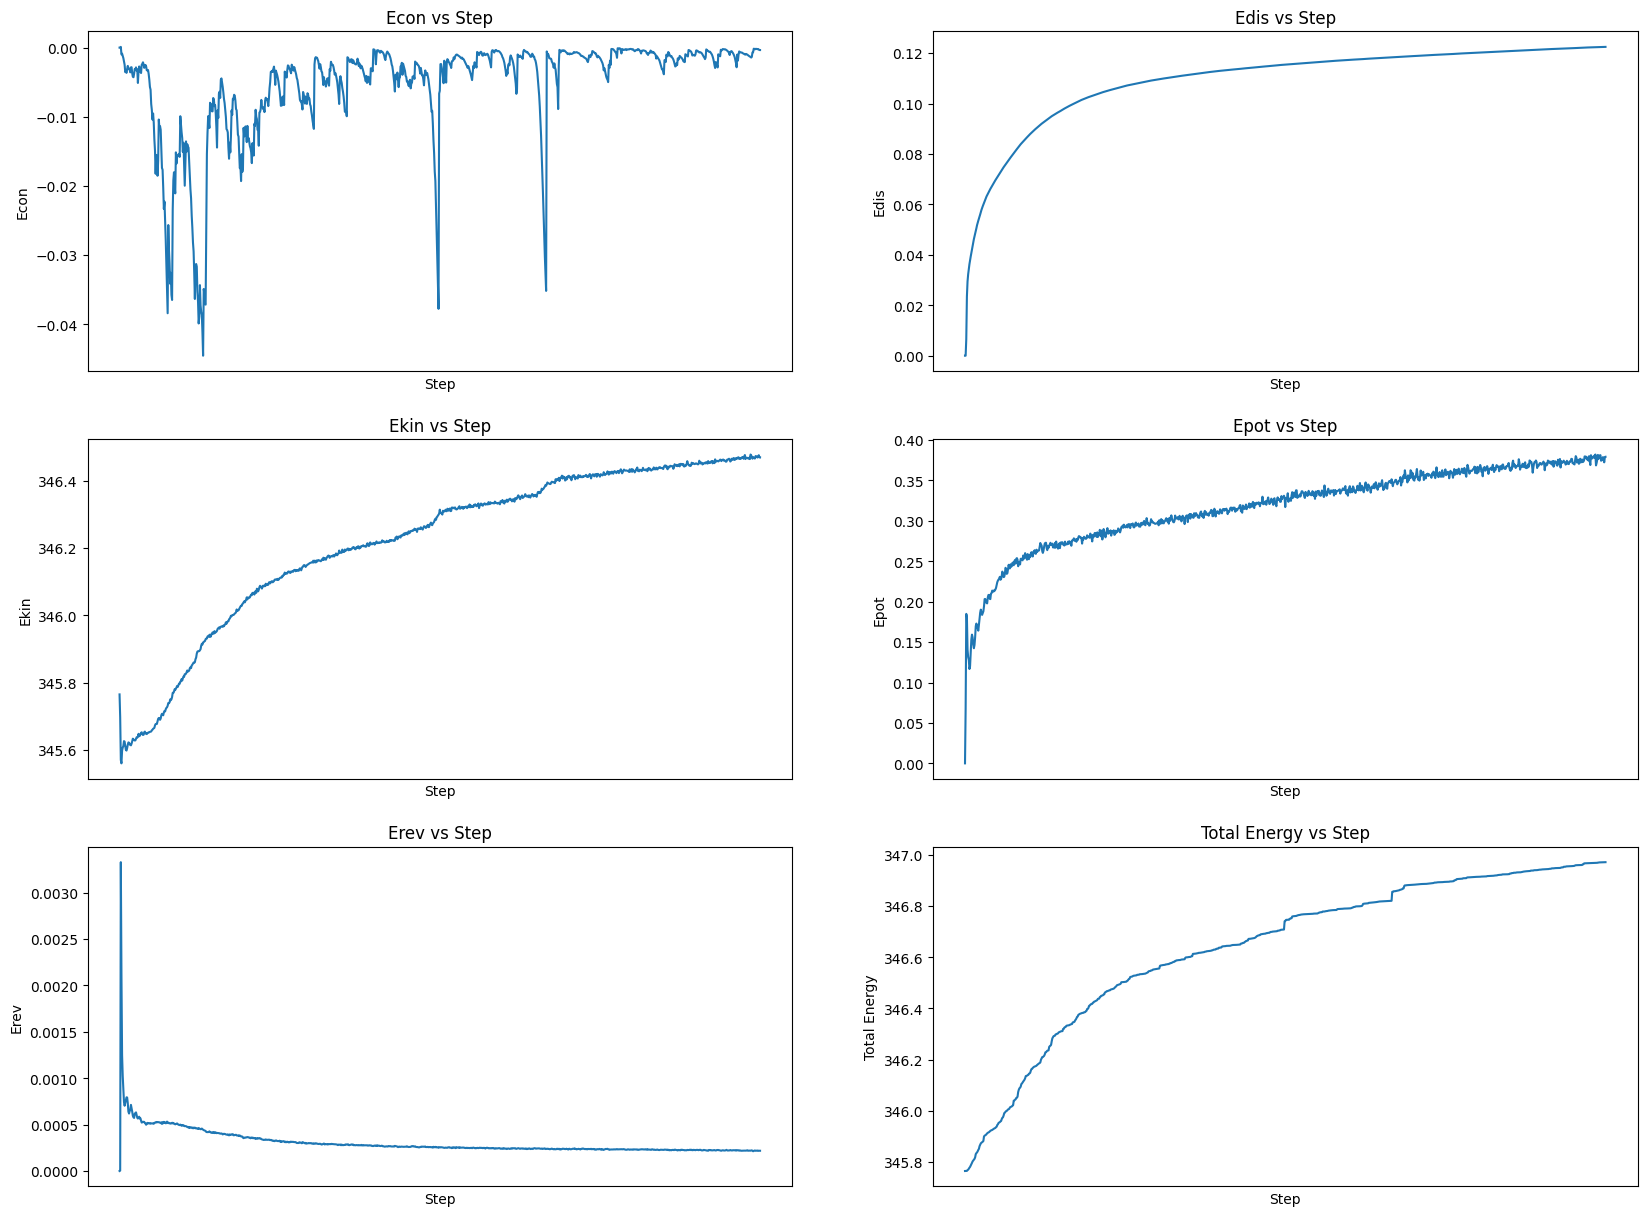

In [9]:
# Plotting the variation of these quantities over time steps
plt.figure(figsize=(20, 15))
plt.subplot(3, 2, 1)
plt.plot(steps, econ, label='Econ')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Econ')
plt.title('Econ vs Step')
plt.subplot(3, 2, 2)
plt.plot(steps, edis, label='Edis')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Edis')
plt.title('Edis vs Step')
plt.subplot(3, 2, 3)
plt.plot(steps, ekin, label='Ekin')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Ekin')
plt.title('Ekin vs Step')
plt.subplot(3, 2, 4)
plt.plot(steps, epot, label='Epot')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Epot')
plt.title('Epot vs Step')
plt.subplot(3, 2, 5)
plt.plot(steps, erev, label='Erev')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Erev')
plt.title('Erev vs Step')
plt.subplot(3, 2, 6)
plt.plot(steps, total_energy, label='Total Energy')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Total Energy')
plt.title('Total Energy vs Step')
plt.show()

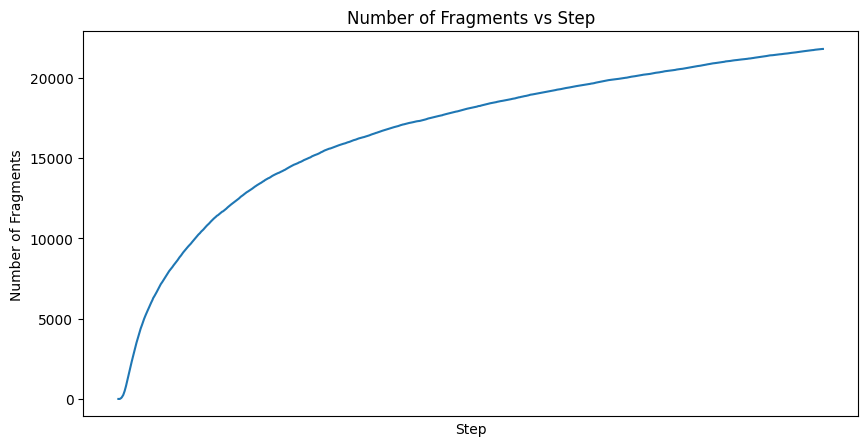

In [10]:
# PLotting number of fragments over time steps
plt.figure(figsize=(10, 5))
plt.plot(steps, nb_fragments, label='Number of Fragments')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Number of Fragments')
plt.title('Number of Fragments vs Step')
plt.show()

In [ ]:
# Compute every fragment with a mass higher than a threshold to plot it
# mass conservation

In [11]:
final_masses = final_step_mesh_2['fragment_mass'][:]
final_velocities = final_step_mesh_2['fragment_velocity'][:]
final_com = final_step_mesh_2['fragment_COM'][:]
print(final_masses)
print(final_velocities)
print(final_com)

[8.42824498e-07 8.42824498e-07 8.42824498e-07 ... 1.49131348e-07
 1.49131348e-07 1.49131348e-07]
[[  7.79520647   2.81052404 179.49402026]
 [  8.13207792  -1.7336317   80.9932512 ]
 [ -8.10337505   5.10495381  66.20387117]
 ...
 [ 26.3537243   -7.88496089  92.39695561]
 [  1.51849119  -3.30498078  78.98634723]
 [ 10.66180544   3.36707975  68.26644253]]
[[ 3.39086737e-03 -1.81428152e-02  6.16929073e-07]
 [-2.21553679e-02  1.93982247e-03 -3.75000000e-04]
 [-2.23680382e-02  6.49173044e-03  3.75000000e-04]
 ...
 [-2.26033837e-02  5.37113192e-03 -3.75000000e-04]
 [-2.24709574e-02  4.33541814e-03 -3.75000000e-04]
 [-2.29149296e-02  4.09040637e-03 -3.75000000e-04]]


In [12]:
# print mean, min, max, std of masses and velocity magnitudes
mean_mass = np.mean(final_masses)
min_mass = np.min(final_masses)
max_mass = np.max(final_masses)
std_mass = np.std(final_masses)
velocity_magnitudes = np.linalg.norm(final_velocities, axis=1)
mean_velocity = np.mean(velocity_magnitudes)
min_velocity = np.min(velocity_magnitudes)
max_velocity = np.max(velocity_magnitudes)
std_velocity = np.std(velocity_magnitudes)
print(f"Masses - Mean: {mean_mass}, Min: {min_mass}, Max: {max_mass}, Std: {std_mass}")
print(f"Velocity Magnitudes - Mean: {mean_velocity}, Min: {min_velocity}, Max: {max_velocity}, Std: {std_velocity}")

Masses - Mean: 3.343774668951596e-07, Min: 1.4461670287818606e-08, Max: 8.42514842690516e-05, Std: 1.8570200798154071e-06
Velocity Magnitudes - Mean: 379.74734306627863, Min: 1.511668725912653, Max: 1092.1177290129904, Std: 262.713115371218


In [14]:
initial_econ_m2 = econ[0]
initial_edis_m2 = edis[0]
initial_ekin_m2 = ekin[0]
initial_epot_m2 = epot[0]
initial_erev_m2 = erev[0]
initial_total_energy_m2 = total_energy[0]
diff_econ_2 = []
diff_edis_2 = []
diff_ekin_2 = []
diff_epot_2 = []
diff_erev_2 = []
diff_total_energy_2 = []
for step in sorted_keys_m2:
    step_data = mesh_2_file[step]
    diff_econ_2.append(step_data.attrs['econ'] - initial_econ_m2)
    diff_edis_2.append(step_data.attrs['edis'] - initial_edis_m2)
    diff_ekin_2.append(step_data.attrs['ekin'] - initial_ekin_m2)
    diff_epot_2.append(step_data.attrs['epot'] - initial_epot_m2)
    diff_erev_2.append(step_data.attrs['erev'] - initial_erev_m2)
    diff_total_energy_2.append(step_data.attrs['total_energy'] - initial_total_energy_m2)

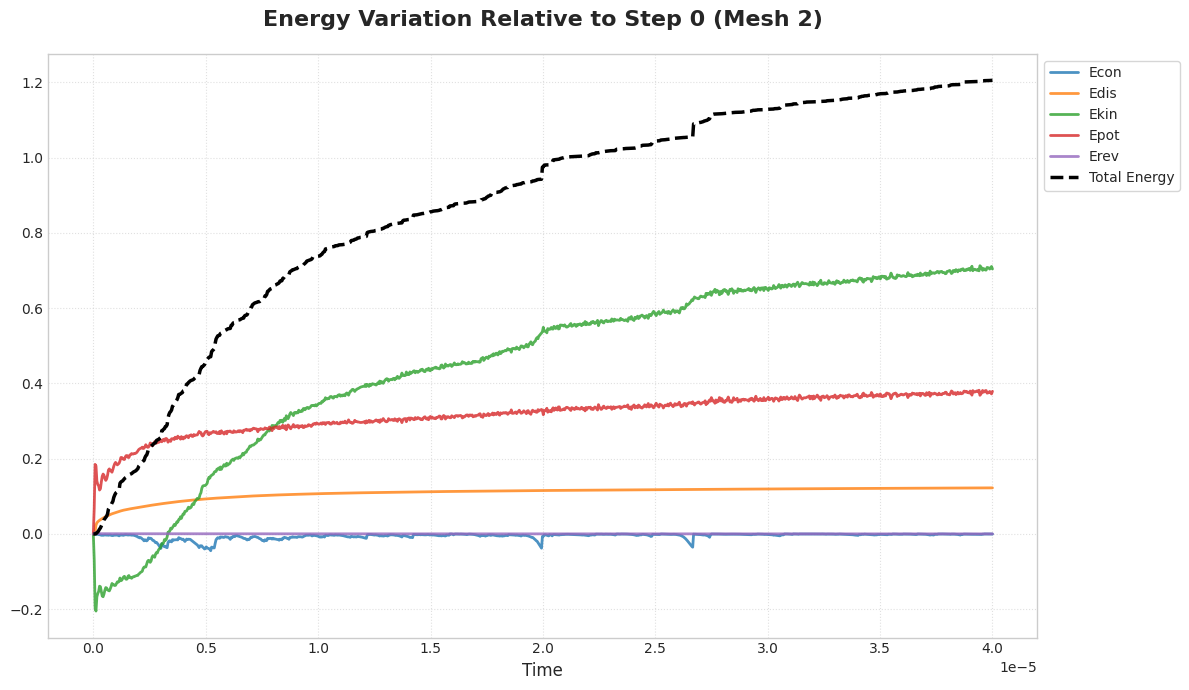

In [16]:
times_m2 = []
for step in sorted_keys_m2:
    step_data = mesh_2_file[step]
    times_m2.append(step_data.attrs['time'])
times_m2 = np.array(times_m2)

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 7))
plt.plot(times_m2, diff_econ_2, label='Econ', linewidth=2, alpha=0.8)
plt.plot(times_m2, diff_edis_2, label='Edis', linewidth=2, alpha=0.8)
plt.plot(times_m2, diff_ekin_2, label='Ekin', linewidth=2, alpha=0.8)
plt.plot(times_m2, diff_epot_2, label='Epot', linewidth=2, alpha=0.8)
plt.plot(times_m2, diff_erev_2, label='Erev', linewidth=2, alpha=0.8)
plt.plot(times_m2, diff_total_energy_2, label='Total Energy', 
         color='black', linestyle='--', linewidth=2.5, zorder=10)
plt.title('Energy Variation Relative to Step 0 (Mesh 2)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Time', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True, fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

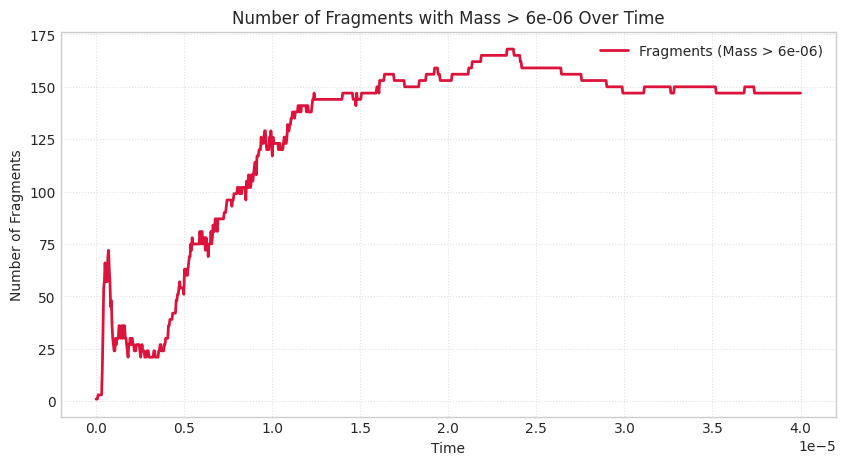

In [20]:
# Extracting number of fragments above a certain mass threshold over time
mass_threshold = 0.000006

filtered_frag_counts = []
times_list = []

for step in sorted_keys_m2:
    step_data = mesh_2_file[step]
    
    # Check if fragment_mass exists in this step
    if 'fragment_mass' in step_data:
        masses = step_data['fragment_mass'][:]
        # Count how many fragments exceed the threshold
        count = np.sum(masses > mass_threshold)
        filtered_frag_counts.append(count)
    else:
        # Fallback to 0 if the dataset isn't populated in early steps
        filtered_frag_counts.append(0)
        
    times_list.append(step_data.attrs['time'])

filtered_frag_counts = np.array(filtered_frag_counts)
times_list = np.array(times_list)

# Plotting filtered fragments over time
plt.figure(figsize=(10, 5))
plt.plot(times_list, filtered_frag_counts, label=f'Fragments (Mass > {mass_threshold})', color='crimson', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Number of Fragments')
plt.title(f'Number of Fragments with Mass > {mass_threshold} Over Time')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

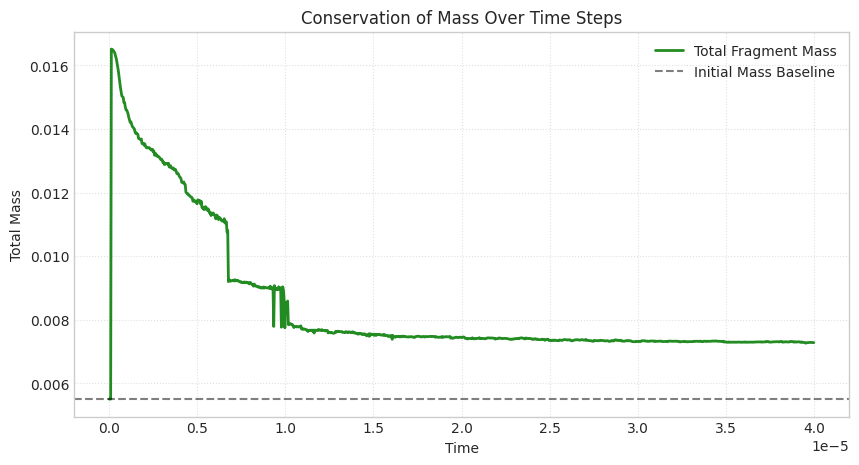

Initial Total Mass: 0.0055075
Final Total Mass: 0.007283744361377261
Absolute Drift: 0.0017762443613772612


In [19]:
# Calculate total system mass at each time step to check for mass conservation
total_masses = []

for step in sorted_keys_m2:
    step_data = mesh_2_file[step]
    if 'fragment_mass' in step_data:
        total_mass = np.sum(step_data['fragment_mass'][:])
        total_masses.append(total_mass)
    else:
        total_masses.append(0.0)

total_masses = np.array(total_masses)

# Plotting total mass over time
plt.figure(figsize=(10, 5))
plt.plot(times_list, total_masses, label='Total Fragment Mass', color='forestgreen', linewidth=2)
# Add a baseline for initial mass to clearly visually inspect drift
plt.axhline(y=total_masses[0], color='black', linestyle='--', alpha=0.5, label='Initial Mass Baseline')

plt.xlabel('Time')
plt.ylabel('Total Mass')
plt.title('Conservation of Mass Over Time Steps')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# Display the scale clearly without offset scientific notation confusion
plt.ticklabel_format(useOffset=False, style='plain', axis='y')
plt.show()

# Print metrics to check numeric drift
mass_drift = total_masses[-1] - total_masses[0]
print(f"Initial Total Mass: {total_masses[0]}")
print(f"Final Total Mass: {total_masses[-1]}")
print(f"Absolute Drift: {mass_drift}")

In [24]:
import pyvista as pv

2026-04-20 11:51:15.894 (   9.629s) [    7FD13FC29740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=
/tmp/ipykernel_1752586/790276196.py:28: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show()


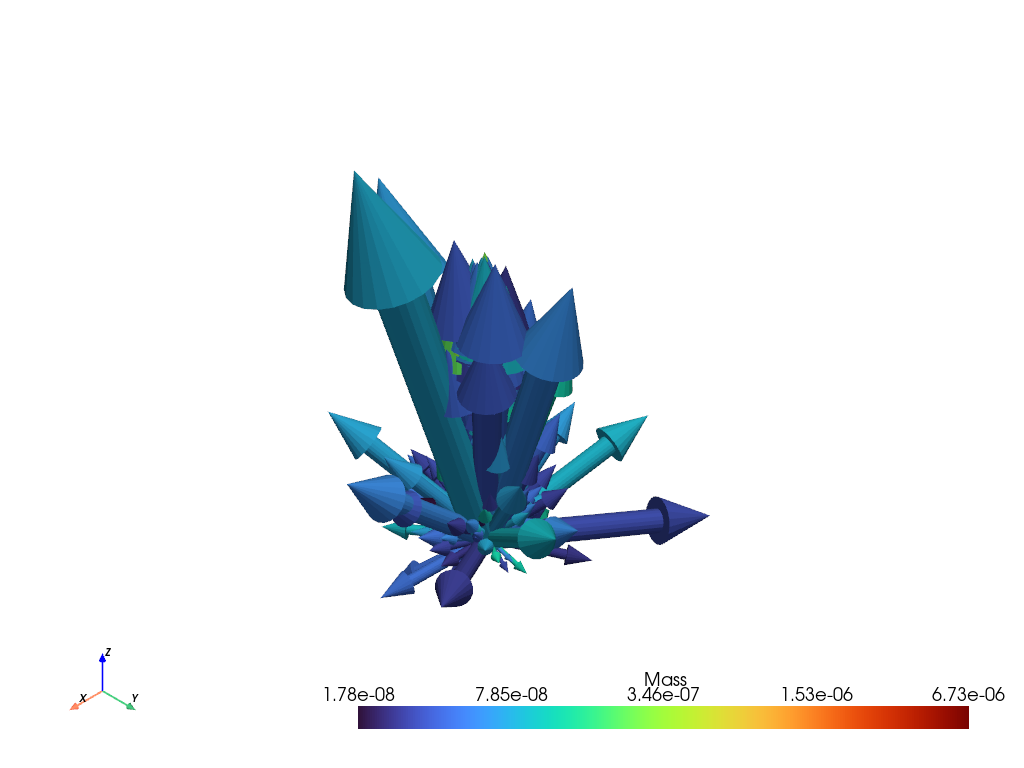

In [14]:
point_cloud = pv.PolyData(final_com)
point_cloud["velocity"] = final_velocities
point_cloud["mass"] = final_masses

# We use the 'velocity' for orientation and magnitude scaling
glyphs = point_cloud.glyph(
    orient="velocity",
    scale=True,  # This scales the arrow length by velocity magnitude
    factor=0.1,
    geom=pv.Arrow(
        tip_radius=0.1,   # Fixed values here
        tip_length=0.25,
        shaft_radius=0.05 
    ),
)

plotter = pv.Plotter()
plotter.add_mesh(
    glyphs,
    scalars="mass",
    cmap="turbo",
    show_scalar_bar=True,
    scalar_bar_args={"title": "Mass"},
    clim=[min_mass, max_mass],
    log_scale=True,
)
plotter.add_axes()
plotter.show()